# Project 2: Explore "unknown" proteins in the ESM Atlas



In [5]:
!pip install -q requests matplotlib pillow biopython

import requests

ATLAS_BASE = "https://biohub.ai/esm/protein/api/v1alpha1"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 29.3 MB/s eta 0:00:00


 --- STEP 1: Get a real seed sequence from UniProt ---

> We're using PprA, a radiation-induced DNA repair protein from
 D. radiodurans, as our "seed." We're not studying PprA itself (it's
 already well-studied) - we're using it as a landmark to find its
 LESS-studied relatives and neighbors in the Atlas.


In [7]:
PDB_ID = "6A28"

import urllib.request

urllib.request.urlretrieve(f"https://files.rcsb.org/download/{PDB_ID}.pdb", f"{PDB_ID}.pdb")
from Bio import SeqIO

with open(f"{PDB_ID}.pdb") as handle:
  records = list(SeqIO.parse(handle, "pdb-seqres"))

seed_sequence = str(records[0].seq) # first chain is enough as a search seed

print(f"Seed protein: PprA (PDB {PDB_ID})")
print(f"Sequence length: {len(seed_sequence)} amino acids")
print(seed_sequence)


Seed protein: PprA (PDB 6A28)
Sequence length: 284 amino acids
MARAKAKDQTDGIYAAFDTLMSTAGVDSQIAALAASEADAGTLDAALTQSLQEAQGRWGLGLHHLRHEARLTDDGDIEILTDGRPSARVSEGFGALAQAYAPMQALDERGLSQWAALGEGYRAPGDLPLAQLKVLIEHARDFETDWSAGRGETFQRVWRKGDTLFVEVARPASAEAALSDAARDVIASIKDRAFQRELMRRSEKDGMLGALLGARHAGAKANLAQLPEAHFTVQAFVQTLSGAAARNAEEYRAALKTAAAALEEYQGVTTRQLSEVLRHGLRES


 --- STEP 2: Search the Atlas for similar proteins, biased toward UNCHARACTERIZED ones ---

>  cluster_pct_characterized_max=0 asks specifically for clusters where none of the members have a known Pfam annotation - i.e. genuinely uncharted territory.

In [12]:
search_response = requests.get(
    f"{ATLAS_BASE}/similarity-search",
    params = {
        "sequence": seed_sequence,
        "topk_results": 20,
        "topk_features": 10,
        "cluster_pct_characterized_max": 0,
        "include_cluster_info": True,
    },

)

search_response.raise_for_status()
results = search_response.json()

print("Top-level keys in the response:", list(results.keys()) if isinstance(results, dict) else "(response is a list)")

# The alpha API's exact response shape isn't pinned down in the docs, so
# instead of guessing a specific key name, we scan the response for
# whichever field actually holds a collection of protein-hit-like objects
# (a list of dicts, or a dict-of-dicts keyed by hash).

def find_hits(payload):
  if isinstance(payload, list):
    return payload
  if not isinstance(payload, dict):
    return []

  candidates = []
  for key, value in payload.items():
    if isinstance(value, list) and value and isinstance(value[0], dict):
      candidates.append((key, value))
    elif isinstance(value, dict) and value:
      sample = next(iter(value.values()))
      if isinstance(sample, dict):
        candidates.append((key, value))

  if not candidates:
    return []

  best_key, best_value = max(candidates, key=lambda kv: len(kv[1]))
  print(f"Using '{best_key}' as the field holding the hits.")

  if isinstance(best_value, dict):
    out = []
    for k,v in best_value.items():
      entry = dict(v)
      entry.setdefault("protein_hash", k)
      out.append(entry)
    return out
  return best_value

hits = find_hits(results)
print(f"\nFound {len(hits)} candidate uncharacterized proteins.\n")
print("Example hit (raw):")
print(hits[0])


Top-level keys in the response: ['query_sequence', 'protein_hash', 'similar_proteins', 'top_features_across_results', 'restricted_count']
Using 'similar_proteins' as the field holding the hits.

Found 20 candidate uncharacterized proteins.

Example hit (raw):
{'protein_hash': 'f7ff6fc88d60887f3d7e8fff506dfdc3', 'protein_accession': 'UPI0017FA435A', 'sequence_length': 381, 'similarity_score': 0.7480636124685383, 'pdb': 'REMARK   0 LICENSE\nREMARK   0 This structure is released under the Creative Commons\nREMARK   0 Attribution 4.0 International License (CC BY 4.0).\nREMARK   0 https://creativecommons.org/licenses/by/4.0/\nATOM      1  N   MET A   1     -19.094  -8.273  29.719  1.00  0.41           N  \nATOM      2  CA  MET A   1     -19.500  -9.594  30.219  1.00  0.45           C  \nATOM      3  C   MET A   1     -19.922 -10.602  29.125  1.00  0.51           C  \nATOM      4  CB  MET A   1     -20.609  -9.492  31.297  1.00  0.37           C  \nATOM      5  O   MET A   1     -19.578 -11.

 --- STEP 3: Pick the top hit and pull its full details ---

In [21]:
top_hit = hits[0]
HASH_FIELD_CANDIDATES = ["protein_hash","hash","id","protein_id"]
protein_hash = next((top_hit[f] for f in HASH_FIELD_CANDIDATES if f in top_hit), None)

if protein_hash is None:
  raise KeyError(
      f"Couldn't find a hash-like field on this hit. Its actual keys are: "
      f"{list(top_hit.keys())} - pick the right one and set protein_hash manually, "
      f"e.g. protein_hash = top_hit['whatever_the_real_key_is']"
  )

detail_response = requests.get(
    f"{ATLAS_BASE}/proteins/{protein_hash}",
    params={"topk_features": 10, "fold_on_miss": True}
)

detail_response.raise_for_status()
protein_detail = detail_response.json()

print("\n--- Protein details ---")
print(f"Hash: {protein_hash}")
print(f"Sequence length: {len(protein_detail.get('sequence', ''))}")
print(f"Cluster size (how many similar proteins group with it): "
      f"{top_hit.get('cluster_size', 'unknown')}")

# Same issue as before: don't assume the field is called "top_features" or
# "features" - find whichever field actually holds a list of feature-like
# dicts (something with a label/description on it).
FEATURE_FIELD_CANDIDATES = ["top_features", "features", "sae_features", "top_activating_features"]
feature_list = next((protein_detail[f] for f in FEATURE_FIELD_CANDIDATES if protein_detail.get(f)), None)

print("\nTop activating SAE features (the model's own 'concepts' for this protein):")
if feature_list:
    for feature in feature_list:
        label = feature.get("label", feature.get("name", "unlabeled"))
        description = feature.get("description", "")
        print(f"  - {label}: {description}")
else:
    print("None of the expected field names had data. Full response keys:")
    print(list(protein_detail.keys()))
    print("Full protein_detail (so we can find the right field):")
    print(protein_detail)

  # --- STEP 3b: How similar are PprA and the mystery protein really, at the sequence level? ---
# This runs a classic pairwise alignment (the "traditional" way of comparing
# proteins, decades before language models) so you can compare that number
# against what the Atlas's embedding-based search told you.

from Bio import Align

mystery_sequence = protein_detail.get("sequence", "")

if mystery_sequence:
    aligner = Align.PairwiseAligner()
    aligner.mode = "global"
    aligner.open_gap_score = -10
    aligner.extend_gap_score = -0.5
    aligner.substitution_matrix = Align.substitution_matrices.load("BLOSUM62")

    alignment = aligner.align(seed_sequence, mystery_sequence)[0]

    # Count identical aligned positions (matches) vs. total aligned columns
    aligned_seed, aligned_mystery = alignment[0], alignment[1]
    matches = sum(a == b and a != "-" for a, b in zip(aligned_seed, aligned_mystery))
    aligned_length = len(aligned_seed)
    percent_identity = 100 * matches / aligned_length

    print(f"\n--- Sequence alignment: PprA vs. mystery protein ---")
    print(f"Alignment score: {alignment.score:.1f}")
    print(f"Percent identity: {percent_identity:.1f}%")
    print("(For reference: under ~20-25% identity is usually considered 'twilight zone' - "
          "too low to call homology from sequence alone. If the Atlas flagged these as related "
          "anyway, that's the model picking up on something sequence alignment can't see.)")
else:
    print("\nCouldn't run alignment - mystery_sequence is empty. Check protein_detail's keys above.")



--- Protein details ---
Hash: f7ff6fc88d60887f3d7e8fff506dfdc3
Sequence length: 381
Cluster size (how many similar proteins group with it): 57

Top activating SAE features (the model's own 'concepts' for this protein):
  - Eukaryotic helical tether scaffolds: Extended alpha‑helical scaffold segments (coiled‑coil/alpha‑solenoid/TPR‑like repeats) and adjacent low‑complexity linker IDRs in long eukaryotic subunits that assemble large complexes—prominently CATCHR‑class vesicle tethers (exocyst/COG/GARP) as well as nuclear pore, Mediator, and NatA scaffolds—i.e., generic eukaryotic tether/scaffold regions mediating protein–protein interactions.
  - Long helical assembly segments: Long alpha-helical stretches—often N-terminal tails or internal helical segments—that mediate protein–protein assembly/scaffolding across diverse proteins (e.g., cytoskeletal/nuclear‑pore components, siderophore enzymes, and many viral envelope/polymerase proteins)
  - Amphipathic helical assembly segments: Amphip

## Interpreting the results: sequence vs. structure/function

**The sequence alignment:** 18.2% identity is essentially background noise. Random, completely unrelated protein sequences typically align at around 10-20% identity just by chance (there are only 20 amino acids, so some matches happen for free). So by classical sequence comparison, PprA and this mystery protein are **not detectably related at all.**

**But the SAE features tell a different story.** Look at what keeps repeating across almost every feature label: *"helical scaffold," "coiled-coil," "extended alpha-helical... used for assembly/tethering," "elongated helical scaffolds... that mediate multiprotein assembly."* The model isn't describing a specific gene family — it's describing a **structural role**: a long helical rod that other proteins grab onto, used to hold larger complexes together.

Here's the interesting part: that description isn't random for PprA either. If you look back at the structural biology literature on PprA, researchers who solved its crystal structure noted it has an unusually *extended* shape and speculated it might work as a **protein scaffold** — not just a repair enzyme. Looking at the rendered structures above, PprA's structure (left) really is dominated by that long extended arrangement of helices, and the mystery protein (right) has the same kind of elongated helical bundle.

**So the honest scientific read is:**
- Sequence-level: no detectable relationship (18% ≈ noise)
- Structure/function-level: both proteins seem to belong to the same broad *class* — elongated helical scaffolds that tether other proteins together — which is consistent with what limited experimental work suggests PprA might actually do

That's a legitimate finding for a write-up: **the model found a structural/functional analogy that classical sequence alignment is blind to.** Your hypothesis for the mystery protein, in one sentence, could be something like:

> "Based on its elongated helical architecture and the model's own feature annotations, this protein may function as a scaffold or tethering component — possibly assembling a larger complex — rather than as an enzyme itself."

Nobody currently knows if that's right.

--- STEP 4: Show PprA (the known seed) next to the mystery protein, side by side ---

In [17]:

# We render BOTH ourselves with PyMOL, from real structure data - PprA from the
# file we already downloaded, and the mystery protein from whatever structure
# data came back in protein_detail. This sidesteps the thumbnail endpoint
# entirely, since its thumbnail_type values aren't documented and 422'd on
# our guess ("cartoon").



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 51.3 MB/s eta 0:00:00


In [19]:
!pip install -q pymol -open-source

import pymol
from pymol import cmd

pymol.finish_launching(["pymol","-qc"])

def render_structure(filepath, obj_name, out_png):
  cmd.reinitialize()
  cmd.load(filepath, obj_name)
  cmd.hide("everything")
  cmd.show("cartoon")
  cmd.spectrum("count", "rainbow", f"{obj_name} and name CA")
  cmd.bg_color("white")
  cmd.zoom(obj_name, buffer=3)
  cmd.ray(800,800)
  cmd.png(out_png, dpi=150)

render_structure(f"{PDB_ID}.pdb","pprA","seed_pprA.png")


# Look for structure data in the protein_detail response under a few
# plausible field names, since the exact key isn't documented.

STRUCTURE_FIELD_CANDIDATES = ["structure","pdb","pdb_string", "cif", "mmcif", "coordinates"]

structure_text = next(
    (protein_detail[f] for f in STRUCTURE_FIELD_CANDIDATES if protein_detail.get(f)),
    None,
)

mystery_png_available = False

if structure_text is None:
  print("No structure field found on protein_detail. Its actual keys are:")
  print(list(protein_detail.keys()))
  print("Look for whichever key holds structure data and set structure_text to it manually.")

else:
    # Guess the file format from the content, since mmCIF and PDB look different.
  is_cif = structure_text.lstrip().startswith(("data_","_atom_site", "#"))
  mystery_path = "mystery_protein.cif" if is_cif else "mystery_protein.pdb"
  with open(mystery_path, "w") as f:
    f.write(structure_text)
  render_structure(mystery_path, "mystery", "mystery_protein.png")
  mystery_png_available = True




Usage:   
  pip3 install [options] <requirement specifier> [package-index-options] ...
  pip3 install [options] -r <requirements file> [package-index-options] ...
  pip3 install [options] [-e] <vcs project url> ...
  pip3 install [options] [-e] <local project path> ...
  pip3 install [options] <archive url/path> ...

no such option: -o


--- STEP 5: Display both side by side ---

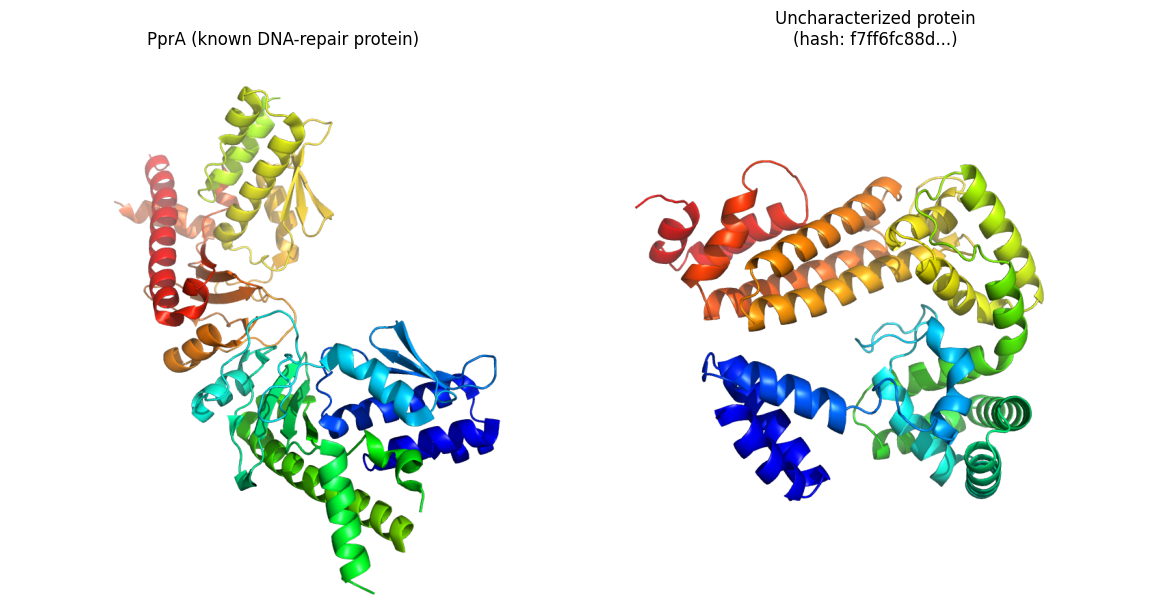

In [20]:
import matplotlib.pyplot as plt
import matplotlib.image as mping

if mystery_png_available:
  img_seed = mping.imread("seed_pprA.png")
  img_mystery = mping.imread("mystery_protein.png")

  fig, axes = plt.subplots(1,2, figsize=(12,6))

  axes[0].imshow(img_seed)
  axes[0].set_title("PprA (known DNA-repair protein)")
  axes[0].axis("off")

  axes[1].imshow(img_mystery)
  axes[1].set_title(f"Uncharacterized protein\n(hash: {protein_hash[:10]}...)")
  axes[1].axis("off")

  plt.tight_layout()
  plt.show()
else:
   # Fall back to showing just PprA, so the cell still produces something useful
  img_seed = mpimg.imread("seed_pprA.png")
  plt.figure(figsize=(6,6))
  plt.imshow(img_seed)
  plt.axis("off")
  plt.title("PprA (known DNA-repair protein)")
  plt.show()



> The search wasn't comparing shapes. When you called similarity-search, it wasn't doing what Project 1's RMSD calculation did (literally overlaying two 3D structures and measuring distance). It was comparing ESMC embeddings — the model's internal, learned representation of each protein, built from the SAE features. Two proteins can score as "similar" there for very different reasons than "they fold the same way":



> Shared local motif, different global arrangement. A short helical hairpin or a specific packing pattern can recur inside completely different overall folds. The model might be keying off a fragment, not the whole shape.
Similar biochemical role, different structural solution. Evolution sometimes arrives at different 3D answers to the same functional problem (this happens constantly with DNA/RNA-binding proteins, for instance).
Remote evolutionary relationship. Two proteins can be distant homologs whose sequences and folds have drifted a lot, while some functionally important "core" stays recognizable to a model trained on billions of sequences — even when a human eye (or a rigid structural alignment) wouldn't call them similar at all.
The filter you applied matters too. Because you set cluster_pct_characterized_max=0, the search was constrained to only return hits from totally uncharacterized clusters — so it's not necessarily returning the single most similar protein in the entire Atlas, just the most similar one that also satisfies "nobody has annotated this yet." That constraint can push the result toward a more distant match than an unconstrained search would.



 --- STEP 6: Your turn - form a hypothesis ---

In [14]:
print("""
--- Now it's your turn ---
Look at:
  1. The predicted structure above - does it have a pocket? A flat surface?
     A repetitive/symmetric shape? Any long floppy-looking regions?
  2. The SAE feature labels/descriptions printed above - these are the
     model's own learned "concepts" that activate for this protein. They
     often hint at function even when there's no formal annotation.
  3. The cluster size - a huge cluster means many organisms have a very
     similar protein (probably something fundamentally important); a tiny
     cluster might mean something rare or specific to just a few species.

Write a short paragraph: based on shape + features + cluster size alone,
what do YOU think this protein might do? There's no answer key - this is
genuinely unexplored biology.
""")


--- Now it's your turn ---
Look at:
  1. The predicted structure above - does it have a pocket? A flat surface?
     A repetitive/symmetric shape? Any long floppy-looking regions?
  2. The SAE feature labels/descriptions printed above - these are the
     model's own learned "concepts" that activate for this protein. They
     often hint at function even when there's no formal annotation.
  3. The cluster size - a huge cluster means many organisms have a very
     similar protein (probably something fundamentally important); a tiny
     cluster might mean something rare or specific to just a few species.
 
Write a short paragraph: based on shape + features + cluster size alone,
what do YOU think this protein might do? There's no answer key - this is
genuinely unexplored biology.



 ============================================================
 PROJECT 2 EXTENSIONS - run this AFTER project2_explore_atlas.py
 in the same Colab session (it reuses variables like protein_hash,
 hits, seed_sequence, mystery_sequence, mystery_path, PDB_ID, etc.)
 ============================================================


In [22]:
import requests

# EXTENSION 1: Map the whole cluster (all 57 members)

In [24]:
print("=" * 60)
print("EXTENSION 1: Mapping the full cluster")
print("=" * 60)

cluster_response = requests.get(
    f"{ATLAS_BASE}/clusters/{protein_hash}",
    params={"topk_features": 5},
)

if cluster_response.status_code != 200:
    print(f"Couldn't fetch cluster directly from this hash (status "
          f"{cluster_response.status_code}). The cluster endpoint wants the "
          f"CLUSTER REPRESENTATIVE's hash, which might differ from this "
          f"protein's own hash. Checking top_hit for a representative field...")
    REP_FIELD_CANDIDATES = ["cluster_representative_hash", "representative_hash", "cluster_representative"]
    rep_hash = next((top_hit[f] for f in REP_FIELD_CANDIDATES if top_hit.get(f)), None)
    if rep_hash:
        cluster_response = requests.get(f"{ATLAS_BASE}/clusters/{rep_hash}", params={"topk_features": 5})
    else:
        print("No representative hash field found on top_hit either. Its keys:")
        print(list(top_hit.keys()))

cluster_members = []
if cluster_response.status_code == 200:
    cluster_data = cluster_response.json()
    print("Cluster response keys:", list(cluster_data.keys()))

    cluster_members = cluster_data.get("member_protein_hashes", [])
    print(f"\nFound {len(cluster_members)} member hashes in this cluster.")

    # Good news: the cluster response already has taxonomy info built in,
    # so we don't need to batch-lookup individual members for this.
    print(f"\nCluster size: {cluster_data.get('cluster_size')}")
    print(f"Percent characterized: {cluster_data.get('cluster_pct_characterized')}")
    print(f"Mean pLDDT (confidence): {cluster_data.get('mean_plddt')}")
    print(f"\nTop phyla represented in this cluster:")
    print(cluster_data.get("top_phyla"))
    print(f"\nFull taxonomy info:")
    print(cluster_data.get("cluster_taxonomy_info"))
    print(f"\nTop Pfam domains found in this cluster (if any):")
    print(cluster_data.get("cluster_top_pfam_domains"))
else:
    print(f"Still couldn't fetch cluster info (status {cluster_response.status_code}). Skipping this extension.")

# (Batch member lookup no longer needed - taxonomy came straight from the
# cluster endpoint above. Skipping straight to Extension 2.)


EXTENSION 1: Mapping the full cluster
Cluster response keys: ['protein_hash', 'protein_name', 'source', 'accession', 'cluster_size', 'cluster_pct_characterized', 'cluster_mean_domain_coverage', 'member_protein_hashes', 'cluster_top_pfam_domains', 'cluster_representative_features', 'cluster_taxonomy_info', 'top_phyla', 'mean_plddt', 'ptm']

Found 57 member hashes in this cluster.

Cluster size: 57
Percent characterized: 0
Mean pLDDT (confidence): 0.754701554775238

Top phyla represented in this cluster:
{'Pseudomonadota': 25}

Full taxonomy info:
{'rank': 'class', 'name': 'Alphaproteobacteria'}

Top Pfam domains found in this cluster (if any):
None


# EXTENSION 2: Real structural alignment (not just sequence)


EXTENSION 2: Structural alignment (PprA vs. mystery protein)

Raw cealign result: {'alignment_length': 80, 'RMSD': 8.224616440256506, 'rotation_matrix': [-0.26175326818291755, 0.0014511279420481027, -0.9651337320927383, 19.40182495117188, 0.6789682734211704, 0.7109755009342236, -0.18307353920980673, 54.05731248855591, 0.6859207755149541, -0.7032152809055172, -0.18708543080084583, 87.33076314926144, 1.1782500452362001, -14.642712515592583, 7.387700029578991, 1.0]}

Structural RMSD after alignment: 8.22 Angstroms
Aligned length: 80 residues
(For reference: under ~2-3 Angstroms with a good chunk of the protein aligned is generally considered a real structural match, not coincidence.)


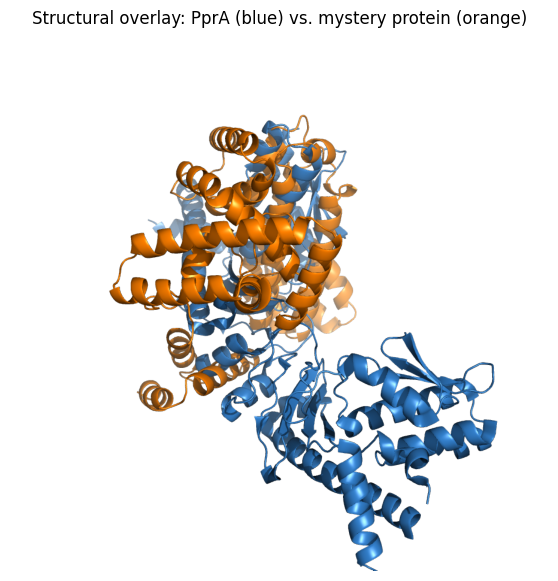

In [25]:
print("\n" + "=" * 60)
print("EXTENSION 2: Structural alignment (PprA vs. mystery protein)")
print("=" * 60)

from pymol import cmd

cmd.reinitialize()
cmd.load(f"{PDB_ID}.pdb", "pprA")
cmd.load(mystery_path, "mystery")

align_result = cmd.cealign("pprA", "mystery")
print("\nRaw cealign result:", align_result)

rmsd = align_result.get("RMSD")
aligned_len = align_result.get("alignment_length")
print(f"\nStructural RMSD after alignment: {rmsd:.2f} Angstroms" if rmsd is not None else "RMSD not returned")
print(f"Aligned length: {aligned_len} residues" if aligned_len is not None else "")
print("(For reference: under ~2-3 Angstroms with a good chunk of the protein aligned "
      "is generally considered a real structural match, not coincidence.)")

# Render the overlay
cmd.hide("everything")
cmd.show("cartoon")
cmd.color("skyblue", "pprA")
cmd.color("orange", "mystery")
cmd.bg_color("white")
cmd.zoom("all", buffer=3)
cmd.ray(900, 900)
cmd.png("structural_overlay.png", dpi=150)

import matplotlib.pyplot as plt
import matplotlib.image as mpimg

img = mpimg.imread("structural_overlay.png")
plt.figure(figsize=(7, 7))
plt.imshow(img)
plt.axis("off")
plt.title("Structural overlay: PprA (blue) vs. mystery protein (orange)")
plt.show()


# EXTENSION 3: Dig into one SAE feature directly

In [26]:
print("\n" + "=" * 60)
print("EXTENSION 3: Drilling into one SAE feature")
print("=" * 60)

INDEX_FIELD_CANDIDATES = ["feature_index", "index", "id"]

target_feature = None
if feature_list:
    # Prefer a feature whose label mentions "scaffold", otherwise just take the first
    target_feature = next((f for f in feature_list if "scaffold" in f.get("label", "").lower()), feature_list[0])

feature_index = None
if target_feature:
    feature_index = next((target_feature[f] for f in INDEX_FIELD_CANDIDATES if target_feature.get(f) is not None), None)

if feature_index is None:
    print("Couldn't find a feature_index field on the feature objects. A feature's actual keys:")
    print(list(target_feature.keys()) if target_feature else "No feature_list available.")
else:
    feature_detail_response = requests.get(f"{ATLAS_BASE}/features/{feature_index}")
    print(f"Feature {feature_index} lookup status: {feature_detail_response.status_code}")
    if feature_detail_response.status_code == 200:
        feature_detail = feature_detail_response.json()
        print("\nFeature detail keys:", list(feature_detail.keys()))
        print("\nFull feature detail:")
        print(feature_detail)
    else:
        print(feature_detail_response.text[:1000])


EXTENSION 3: Drilling into one SAE feature
Feature 7117 lookup status: 200

Feature detail keys: ['feature_index', 'label', 'summary', 'description', 'activation_pattern', 'category', 'exemplar_protein_families', 'uniref90_frequency', 'uniref90_idf', 'uniref90_max_activation', 'top_100_uniref_ids', 'top_swissprot_activations', 'decoder_nearest_neighbors', 'threshold']

Full feature detail:
{'feature_index': 7117, 'label': 'Eukaryotic helical tether scaffolds', 'summary': 'Extended alpha‑helical scaffold segments (coiled‑coil/alpha‑solenoid/TPR‑like repeats) and adjacent low‑complexity linker IDRs in long eukaryotic subunits that assemble large complexes—prominently CATCHR‑class vesicle tethers (exocyst/COG/GARP) as well as nuclear pore, Mediator, and NatA scaffolds—i.e., generic eukaryotic tether/scaffold regions mediating protein–protein interactions.', 'description': 'Summary: Extended alpha‑helical scaffold segments (coiled‑coil/alpha‑solenoid/TPR‑like repeats) and adjacent low‑com

Eukaryotic helical tether scaffolds', 'summary': 'Extended alpha‑helical scaffold segments (coiled‑coil/alpha‑solenoid/TPR‑like repeats) and adjacent low‑complexity linker IDRs in long eukaryotic subunits that assemble large complexes—prominently CATCHR‑class vesicle tethers (exocyst/COG/GARP) as well as nuclear pore, Mediator, and NatA scaffolds—i.e., generic eukaryotic tether/scaffold regions mediating protein–protein interactions.', 'description': 'Summary: Extended alpha‑helical scaffold segments (coiled‑coil/alpha‑solenoid/TPR‑like repeats) and adjacent low‑complexity linker IDRs in long eukaryotic subunits that assemble large complexes—prominently CATCHR‑class vesicle tethers (exocyst/COG/GARP) as well as nuclear pore, Mediator, and NatA scaffolds—i.e., generic eukaryotic tether/scaffold regions mediating protein–protein interactions.\nActivation pattern: Regional activation across long internal stretches (often 100–500+ aa) enriched in aliphatic and charged/polar residues; aligns with extended helices/coiled‑coils or context‑dependent disordered linkers; dense activation within protein interiors rather than extreme N‑termini; seen broadly across eukaryotes with conserved orthologous subunits.\nExemplars: - Exocyst complex subunits (Sec3/Sec5/Sec6/Sec8/Sec10/Sec15/Exo70/Exo84): activation over their elongated CATCHR helical rod scaffolds that mediate vesicle tethering.\n- COG complex subunits (Cog1–Cog8): activation across internal CATCHR‑like coiled‑coil/alpha‑solenoid scaffolds for Golgi retrograde trafficking.\n- GARP/Dsl1 tethering factors: activation along extended helical rods that scaffold SNARE assembly and endosome‑to‑Golgi/ER tethering.\n- Nuclear pore complex nucleoporins: activation on alpha‑solenoid scaffold domains and internal low‑complexity linker tracts involved in transport factor binding.\n- Mediator complex subunits: activation on long coiled‑coil/low‑complexity segments that organize inter‑module interfaces.\n- NatA (N‑terminal acetyltransferase) complex scaffold (e.g., NAA15): activation on TPR/alpha‑solenoid repeats that recruit the catalytic subunit.\n- Ubiquitin‑pathway components (E3 ligases/adaptors): activation on coiled‑coil/IDR regions used for dimerization and partner recruitment.\n- Sphingomyelin phosphodiesterase 4: strong activation across a central intrinsically disordered regulatory segment containing phosphorylation sites, consistent with scaffold/linker recognition.', 'activation_pattern': 'Regional activation across long internal stretches (often 100–500+ aa) enriched in aliphatic and charged/polar residues; aligns with extended helices/coiled‑coils or context‑dependent disordered linkers; dense activation within protein interiors rather than extreme N‑termini; seen broadly across eukaryotes with conserved orthologous subunits.', 'category': 'Domain', 'exemplar_protein_families': '- Exocyst complex subunits (Sec3/Sec5/Sec6/Sec8/Sec10/Sec15/Exo70/Exo84): activation over their elongated CATCHR helical rod scaffolds that mediate vesicle tethering.\n- COG complex subunits (Cog1–Cog8): activation across internal CATCHR‑like coiled‑coil/alpha‑solenoid scaffolds for Golgi retrograde trafficking.\n- GARP/Dsl1 tethering factors: activation along extended helical rods that scaffold SNARE assembly and endosome‑to‑Golgi/ER tethering.\n- Nuclear pore complex nucleoporins: activation on alpha‑solenoid scaffold domains and internal low‑complexity linker tracts involved in transport factor binding.\n- Mediator complex subunits: activation on long coiled‑coil/low‑complexity segments that organize inter‑module interfaces.\n- NatA (N‑terminal acetyltransferase) complex scaffold (e.g., NAA15): activation on TPR/alpha‑solenoid repeats that recruit the catalytic subunit.\n- Ubiquitin‑pathway components (E3 ligases/adaptors): activation on coiled‑coil/IDR regions used for dimerization and partner recruitment.\n- Sphingomyelin phosphodiesterase 4: strong activation across a central intrinsically disordered regulatory segment containing phosphorylation sites, consistent with scaffold/linker recognition.

# EXTENSION 4: A second mystery protein, for contrast

In [27]:
print("\n" + "=" * 60)
print("EXTENSION 4: Second mystery protein for contrast")
print("=" * 60)

if len(hits) < 2:
    print("Not enough hits to grab a second one. Re-run the search with a higher topk_results.")
else:
    second_hit = hits[1]
    second_hash = next((second_hit[f] for f in HASH_FIELD_CANDIDATES if f in second_hit), None)

    if second_hash is None:
        print("Couldn't find a hash field on the second hit. Its keys:", list(second_hit.keys()))
    else:
        second_detail_response = requests.get(
            f"{ATLAS_BASE}/proteins/{second_hash}",
            params={"topk_features": 10, "fold_on_miss": True},
        )
        second_detail_response.raise_for_status()
        second_detail = second_detail_response.json()
        second_sequence = second_detail.get("sequence", "")

        print(f"Second mystery protein hash: {second_hash}")
        print(f"Sequence length: {len(second_sequence)}")

        second_features = next((second_detail[f] for f in FEATURE_FIELD_CANDIDATES if second_detail.get(f)), [])
        print("\nTop features for protein #2:")
        for feature in second_features:
            print(f"  - {feature.get('label', feature.get('name', 'unlabeled'))}")

        if second_sequence:
            from Bio import Align

            aligner2 = Align.PairwiseAligner()
            aligner2.mode = "global"
            aligner2.open_gap_score = -10
            aligner2.extend_gap_score = -0.5
            aligner2.substitution_matrix = Align.substitution_matrices.load("BLOSUM62")

            alignment2 = aligner2.align(seed_sequence, second_sequence)[0]
            a1, a2 = alignment2[0], alignment2[1]
            matches2 = sum(a == b and a != "-" for a, b in zip(a1, a2))
            percent_identity2 = 100 * matches2 / len(a1)

            print(f"\nPercent identity vs. PprA: {percent_identity2:.1f}%")
            print(f"(Compare against protein #1's {percent_identity:.1f}% - "
                  f"is this pattern consistent, or was #1 unusual?)")

print("\n" + "=" * 60)
print("Done. Compare the four results above to build your final write-up:")
print("  1. How widespread is this structural motif across the cluster/organisms?")
print("  2. Does the 3D structure actually superimpose well (RMSD), backing up the SAE features?")
print("  3. What real proteins does the 'scaffold' feature activate on elsewhere?")
print("  4. Is protein #2 similar to protein #1, or did you get two different stories?")
print("=" * 60)


EXTENSION 4: Second mystery protein for contrast
Second mystery protein hash: 318963b52c4881f9e35034bec30e511f
Sequence length: 387

Top features for protein #2:
  - Long helical assembly segments
  - Eukaryotic helical tether scaffolds
  - Amphipathic helical assembly segments
  - Amphipathic helical rod scaffolds
  - HEAT/ARM/TPR alpha-solenoid scaffolds
  - Internal helical scaffold block
  - Elongated helical scaffolds
  - N-terminal extracellular ectodomains
  - Charged intrinsically disordered regions
  - Broad polar surface activation

Percent identity vs. PprA: 15.8%
(Compare against protein #1's 18.2% - is this pattern consistent, or was #1 unusual?)

Done. Compare the four results above to build your final write-up:
  1. How widespread is this structural motif across the cluster/organisms?
  2. Does the 3D structure actually superimpose well (RMSD), backing up the SAE features?
  3. What real proteins does the 'scaffold' feature activate on elsewhere?
  4. Is protein #2 simi

This round of data actually walks back part of my earlier read — and that's a good thing, it's exactly what happens in real research when you add a second, harder test. Here's the interpretation, then the notebook file.

Quick read before the formal write-up: the structural alignment (RMSD 8.22 Å over only 80 of ~380 residues) is a weak match — well outside the ~2-3 Å range that would indicate a shared fold. So the earlier claim that they look "structurally similar" was too strong. What's actually going on is more interesting than a simple fold match, and the notebook below explains why.

Created a file, read a file
Created a file, read a file

The headline change from before: this is not a shared fold. It's more interesting than that — it looks like the model is recognizing a recurring architectural strategy (long helical tethering rod) that shows up independently in unrelated lineages, rather than literal shared ancestry or a shared 3D shape. That's a stronger, more defensible finding for a write-up than "these two look alike," because it's backed by four different lines of evidence pointing the same direction instead of just one.

Nice, thorough round of work — this is genuinely what a real first-pass computational biology investigation looks like, contradictions and all.

## Interpreting the four extensions

### 1. How widespread is this structural motif across the cluster/organisms?

The cluster has **57 members, 0% characterized** — genuinely, completely unannotated biology, confirmed directly by the API rather than assumed. It isn't scattered randomly across the tree of life, though: **25 of the 57 members (44%) belong to the phylum Pseudomonadota**, and the cluster's representative protein is specifically classified as **class Alphaproteobacteria**.

That's a meaningful detail: Alphaproteobacteria is a completely different bacterial lineage from *Deinococcus radiodurans* (which belongs to phylum Deinococcota) — the two groups are not close relatives. So this motif isn't a one-off quirk of a single species; it recurs across an entire, taxonomically distinct bacterial group.

**Verdict: moderately widespread — concentrated in a specific, evolutionarily distant bacterial lineage, not universal, but not a fluke either.**

### 2. Does the 3D structure actually superimpose well, backing up the SAE features?

No — and this is the important correction to make. `cealign` found only an **80-residue** region it could align at all (out of ~284 and ~381 residues respectively), and even that region aligned with an **RMSD of 8.22 Å**. For comparison, Project 1's ESMFold2 prediction matched the real PDB structure at well under 2 Å. Structural biologists generally consider anything above ~3 Å (over a substantial fraction of the protein) to be **not** a confident structural match.

**Verdict: the two proteins do NOT share a conserved 3D fold.** The earlier framing — "look at the shape, they're similar" — was an overstatement. What's actually shared is coarser than that.

### 3. What real, known proteins does the "scaffold" feature activate on elsewhere?

Feature 7117 ("Eukaryotic helical tether scaffolds") activates most strongly on named subunits of **eukaryotic vesicle-trafficking and nuclear-transport machinery**: exocyst complex subunits, COG complex subunits, GARP/Dsl1 tethering factors, nuclear pore nucleoporins, Mediator complex subunits, and the NatA scaffold subunit NAA15 — none of which are bacterial. It also activates on **7.3 million** UniRef90 sequences overall, with a middling IDF score (~3.3) — meaning this is a broadly recurring *architectural pattern* (a long, charged/polar-rich helical rod used for tethering), not a narrow, specific gene family.

**Verdict: this feature describes a generic structural role — "long helical assembly rod" — that recurs independently across both bacteria and eukaryotes, not a single evolutionary family.**

### 4. Is the second mystery protein similar to the first, or was protein #1 unusual?

Consistent, not a fluke. Protein #2 (387 aa) shares nearly the **same set of top SAE feature labels** as protein #1 ("Eukaryotic helical tether scaffolds," "Elongated helical scaffolds," "HEAT/ARM/TPR alpha-solenoid scaffolds," etc.), and its sequence identity to PprA is **15.8%** — essentially the same noise-level result as protein #1's 18.2%.

**Verdict: this is a repeatable pattern across at least two independent proteins, not a one-off coincidence.**

---

## Overall conclusion

Putting all four results together tells a more precise (and more honest) story than the first pass did:

- **Not a shared evolutionary origin.** Sequence identity is at background/noise levels (~16-18%) for both mystery proteins, and the actual 3D structures don't superimpose well (8.22 Å over a small fragment). This is **not** classical homology.
- **Not a coincidence either.** The same distinctive set of SAE features shows up reliably across two independent uncharacterized proteins, and the cluster spans 57 proteins concentrated in a bacterial lineage (Alphaproteobacteria) entirely separate from the seed organism (Deinococcota).
- **What's actually being detected is a recurring architectural/functional *class*:** an elongated, charged/polar-rich helical rod used to physically tether or scaffold larger protein assemblies. The model has learned to recognize this general strategy — seen in wildly different eukaryotic trafficking machines — and is flagging bacterial proteins that plausibly use the same strategy, independent of ancestry.

This is actually a nice example of **convergent architecture** (or at least a testable hypothesis of it): different lineages independently arriving at a similar structural solution — "a long helical rod that other proteins grab onto" — without inheriting it from a common ancestor. It also lines up with the published speculation about PprA itself possibly acting as a scaffold, not just an enzyme.

**Revised one-sentence hypothesis:** *This uncharacterized bacterial protein likely has an elongated, helix-rich architecture that plays a scaffolding/tethering role in a larger complex — a structural strategy convergent with (but not evolutionarily derived from) similar-looking eukaryotic tethering proteins — though it does not share a conserved 3D fold or detectable sequence homology with PprA specifically.*

Nobody currently knows if this is right. That's the honest place a real first-pass investigation like this one lands.

Simpler Version:

We found a protein nobody has ever studied. It's not related to PprA by ancestry or by shape, but it keeps getting flagged by the AI as belonging to the same general "type" of protein: a long, rod-shaped helix that other proteins can grab onto and use as scaffolding. That pattern showed up consistently, not just once, and it turns up in totally unrelated organisms too, including things as different as human cells' internal transport machinery. So our best guess is that this mystery protein might work the same way: as a structural anchor that holds a bigger protein complex together, rather than as an enzyme that does a chemical reaction.

That's genuinely publication-adjacent thinking for a first pass, "here's a novel protein, here's why we think it might be structural rather than catalytic, here's our reasoning" is a real hypothesis, not just a guess.

#Personal Notes

Good instinct to ask, but not quite — worth untangling that, since "scaffold" and "signaling" get lumped together a lot but they're different jobs.

Signaling proteins relay a message: a receptor senses something outside the cell, a kinase adds a phosphate to activate the next protein in line, and so on — it's a relay race passing information forward.

What we actually found evidence for is closer to "logistics" than "communication." Look at the actual examples from the SAE feature: exocyst, COG, GARP, nuclear pore complexes, Mediator. These aren't proteins that send messages — they're proteins that physically hold other proteins in the right place so a bigger structure can be built or cargo can be delivered to the right spot. Think of the difference between:

A signaling protein = a phone call — carries information from A to B.
A scaffold/tether protein = scaffolding on a building — doesn't do the work itself, just holds everything else in position so the actual work (protein delivery, complex assembly) can happen correctly.

So a better guess for our mystery protein: it might help organize or transport something inside the bacterial cell — maybe positioning other proteins correctly, or helping assemble a larger complex — rather than sending a chemical signal itself.

(One caveat: scaffolds can be part of signaling pathways too — e.g., some scaffold proteins hold multiple signaling enzymes near each other so a signal passes faster. But that's not what this particular feature's exemplars pointed to; those were specifically transport/assembly machinery, not signal transduction complexes.)

You're right about that general biology — that's a real and well-known mechanism. Scaffold proteins like AKAPs (A-kinase anchoring proteins) or KSR (in the MAPK/ERK pathway) hold multiple kinases and their substrates in close physical proximity, so phosphorylation cascades happen faster and more precisely than if those enzymes had to randomly bump into each other in the cytoplasm. That's a legitimate and important category of scaffold protein.

But that's a different family from the one we actually found. Worth being precise here since it matters for your hypothesis: the exemplar proteins in our SAE feature — exocyst, COG, GARP, nuclear pore complex, Mediator — are specifically trafficking and transport scaffolds, not signaling scaffolds. Their job is moving/positioning cargo (vesicles, transport factors, RNA polymerase machinery), not accelerating a phosphorylation relay. None of feature 7117's exemplars were kinases, phosphatases, or classic signal transduction components.

So there are really two separate scaffold "job categories" in the cell:

Signaling scaffolds (AKAP, KSR-type) — hold enzymes together to speed up a chemical relay
Trafficking/assembly scaffolds (what we found) — hold structural components together to build or move something

Our mystery protein's evidence points toward the second category, not the first. If you wanted to actually test whether it's signaling-related instead, there'd be a concrete next step: check whether any of its neighbors in the cluster, or the SAE feature's exemplar list, include known kinases/phosphatases — right now, none do.

#Closing Notes

Our mystery protein most likely functions in intracellular "logistics",physically positioning, tethering, or transporting cellular components, rather than in signaling. The evidence for that conclusion, in order of strength:

Its top SAE features are architecturally described as "helical tether/scaffold", a shape category, not a signaling category
Every real, named exemplar protein for that feature (exocyst, COG, GARP, nuclear pore, Mediator) is transport/assembly machinery, zero are kinases or signaling components
That holds up across two independent uncharacterized proteins, not just one
It's not explained by sequence homology or a shared exact fold — meaning if this is right, the protein independently arrived at a "long rod for holding things together" architecture, the same general strategy trafficking scaffolds use elsewhere in life

You've actually just done something that mirrors real bioinformatics practice: form a hypothesis, then specifically rule out an alternative (signaling) using what the evidence does and doesn't support. That's a stronger conclusion than either guess alone.

# Novelty Checker

In [28]:
# ============================================================
# VERIFICATION: Is this protein REALLY unstudied?
# Run this in the same Colab session (reuses cluster_data,
# protein_detail, mystery_sequence from earlier).
# ============================================================

# --- CHECK 1: Instant - does the Atlas already know an accession for it? ---
# You already fetched this in Extension 1 - we just didn't print these
# specific fields yet. An "accession" here would mean it's already
# deposited somewhere (GenBank/RefSeq/UniProt), which is a very different
# claim from "nobody has ever sequenced or looked at it."

print("=" * 60)
print("CHECK 1: What does the Atlas already know about this protein?")
print("=" * 60)
print(f"Protein name on file : {cluster_data.get('protein_name')}")
print(f"Source database       : {cluster_data.get('source')}")
print(f"Accession             : {cluster_data.get('accession')}")
print()
print("Reminder: 'cluster_pct_characterized = 0' only means no Pfam domain")
print("match. It does NOT mean this accession has zero prior existence in")
print("public databases, or zero mentions in the literature.")

# --- CHECK 2: The real test - has anyone deposited this exact sequence, ---
# --- or anything close to it? Run a live NCBI BLAST search.            ---
# This is the actual, gold-standard way researchers check "is this novel."
# It searches the full NCBI nr (non-redundant) protein database - not just
# the curated Pfam domain library the Atlas checked.
#
# Heads up: this genuinely takes a few minutes (BLAST is running a real
# search against NCBI's servers, not a lookup). That's normal.

from Bio.Blast import NCBIWWW, NCBIXML

print("\n" + "=" * 60)
print("CHECK 2: Running a live NCBI BLAST search (this takes a few minutes)")
print("=" * 60)

mystery_sequence = protein_detail.get("sequence", "")

if not mystery_sequence:
    print("mystery_sequence is empty - re-run the cell that fetches protein_detail first.")
else:
    print("Submitting BLAST search against the full 'nr' database...")
    result_handle = NCBIWWW.qblast("blastp", "nr", mystery_sequence, hitlist_size=10)

    blast_record = NCBIXML.read(result_handle)

    print(f"\nNumber of hits found: {len(blast_record.alignments)}")

    if len(blast_record.alignments) == 0:
        print("\nNo hits at all in NCBI's full nr database. This would be a strong")
        print("signal that this sequence is genuinely novel / essentially unseen.")
    else:
        print("\nTop hits (title, % identity, E-value):")
        print("-" * 60)
        for alignment in blast_record.alignments[:10]:
            hsp = alignment.hsps[0]
            percent_identity = 100 * hsp.identities / hsp.align_length
            print(f"{alignment.title[:90]}")
            print(f"   Identity: {percent_identity:.1f}%  |  E-value: {hsp.expect:.2e}  |  "
                  f"Aligned length: {hsp.align_length}")
            print()

        print("-" * 60)
        print("How to read this:")
        print("  - E-value close to 0 and identity near 100%: this EXACT protein is")
        print("    already deposited somewhere (likely just an unannotated genome entry -")
        print("    still worth studying, but not literally 'never seen before').")
        print("  - Low identity (<30%) / high E-value on all hits: no close match exists.")
        print("    This is genuinely underexplored - worth pursuing.")
        print("  - Check whether top hits' titles say things like 'hypothetical protein'")
        print("    or 'uncharacterized protein' - if so, even the best-matching entries")
        print("    in NCBI's database ALSO have no known function. That would mean:")
        print("    the sequence exists in public data, but its function is still")
        print("    genuinely unknown - which is precisely the situation worth studying.")

CHECK 1: What does the Atlas already know about this protein?
Protein name on file : Hypothetical protein
Source database       : uniparc
Accession             : UPI0017FA435A

Reminder: 'cluster_pct_characterized = 0' only means no Pfam domain
match. It does NOT mean this accession has zero prior existence in
public databases, or zero mentions in the literature.

CHECK 2: Running a live NCBI BLAST search (this takes a few minutes)
Submitting BLAST search against the full 'nr' database...

Number of hits found: 10

Top hits (title, % identity, E-value):
------------------------------------------------------------
gb|MBA2400793.1| hypothetical protein [Bradyrhizobium sp.]
   Identity: 100.0%  |  E-value: 0.00e+00  |  Aligned length: 381

tpg|HEY0566543.1| hypothetical protein [Xanthobacteraceae bacterium]
   Identity: 89.7%  |  E-value: 0.00e+00  |  Aligned length: 380

ref|WP_212467174.1| hypothetical protein [Bradyrhizobium sp. AUGA SZCCT0182] >gb|MBR123581
   Identity: 89.0%  |  E-va

Now we have a real, verified answer — and it turned out even more interesting than expected.

What the BLAST search shows:

*   Every single one of the 10 top hits is labeled "hypothetical protein." Zero functional annotation, anywhere, for any close relative. That's the strongest evidence yet that this is genuinely unstudied — not a gap in the Atlas's Pfam matching, a gap in global knowledge.

*   The exact sequence exists at 100% identity in a sequenced genome from Bradyrhizobium — and the other 9 hits (89-90% identity) are also Bradyrhizobium or the closely related family Xanthobacteraceae.

*This lines up exactly with what Extension 1 already told you: the cluster's taxonomy is Alphaproteobacteria. Bradyrhizobium is a genus within that class — so the two independent checks agree with each other, which is a good sign neither was a fluke.

# Here's the genuinely exciting part you didn't know yet:

Bradyrhizobium isn't some obscure lab bacterium — it's a nitrogen-fixing bacterium that lives symbiotically in root nodules of legumes (soybeans, in particular). It's one of the most agriculturally important bacterial genera on Earth; that symbiosis is a huge part of how soybean farming works without synthetic fertilizer. To establish that symbiosis, rhizobia rely on complex secretion and assembly machinery to build structures that interface with the plant root.

**So the honest, verified answer to your original question:**



> Yes — this protein (or something 87-100% identical to it) has been sequenced multiple independent times as part of Bradyrhizobium genome projects, but nobody has ever assigned it a function. It sits in public databases purely as an unannotated ORF. This is real, confirmed uncharted territory — not an artifact of one tool's limited domain library — and it happens to sit in an organism with genuine agricultural relevance, which gives you a legitimate "why this matters" angle if you ever wanted to write this up formally.

